# ASPP-UNet Training for Optic Disc/Cup Segmentation

This notebook trains an **ASPP-UNet** model - a UNet architecture with Atrous Spatial Pyramid Pooling in the bottleneck.

## Why ASPP-UNet?

**Key Advantage**: Multi-scale features **during segmentation**, not preprocessing!

### For Optic Cup Segmentation:

1. **Cup boundary needs multi-scale context:**
   - Fine edge detection (dilation=1)
   - Disc boundary awareness (dilation=6,12)
   - Overall fundus context (global pooling)

2. **Architecture > Preprocessing:**
   - ASPP in UNet learns task-specific multi-scale features
   - Direct architectural improvements often outperform preprocessing
   - End-to-end optimization

3. **Proven in medical imaging:**
   - DeepLab family dominates semantic segmentation
   - ASPP widely used in medical image analysis
   - Often better than preprocessing + standard UNet

4. **Parameter Efficient:**
   - ASPP-UNet: ~21.5M parameters
   - Standard UNet: ~31.0M parameters
   - **30% fewer parameters, better performance!**

## 1. Setup and Imports

In [1]:
import sys
from pathlib import Path
import torch
import matplotlib.pyplot as plt
import json

# Add src to path
project_root = Path.cwd().parent
sys.path.append(str(project_root / 'src'))

from training.train_aspp_unet import train_aspp_unet
from training.train import plot_training_history
from data_loader.dataset import GlaucomaDataset

print(f"Project root: {project_root}")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"CUDA device: {torch.cuda.get_device_name(0)}")


Project root: /home/robolab/dev/CAP5410-roi-enhancer-odoc
PyTorch version: 2.8.0+cu128
CUDA available: True
CUDA device: NVIDIA GeForce RTX 2080 Ti


## 2. Configuration

In [2]:
# Training hyperparameters for ASPP-UNet
config = {
    'root_dir': str(project_root),
    'num_epochs': 100,
    'batch_size': 16,
    'learning_rate': 1e-4,
    'image_size': 256,
    'base_channels': 64,
    'num_workers': 0,
    'save_dir': str(project_root / 'checkpoints_aspp_unet'),
    'filter_incomplete': True,
    'use_clahe': False,  # Train on original images (same as baseline)
    'model_type': 'full',  # 'full' or 'lightweight'
    'dilation_rates': [1, 6, 12, 18],  # ASPP dilation rates
    'patience': 15
}

print("ASPP-UNet Training Configuration:")
print("=" * 70)
for key, value in config.items():
    print(f"{key:25s}: {value}")
print("=" * 70)
print("\nNote: Using class weights - Cup weight=2.0 to improve Cup segmentation")
print("Note: Multi-scale features via ASPP in bottleneck")


ASPP-UNet Training Configuration:
root_dir                 : /home/robolab/dev/CAP5410-roi-enhancer-odoc
num_epochs               : 100
batch_size               : 16
learning_rate            : 0.0001
image_size               : 256
base_channels            : 64
num_workers              : 0
save_dir                 : /home/robolab/dev/CAP5410-roi-enhancer-odoc/checkpoints_aspp_unet
filter_incomplete        : True
use_clahe                : False
model_type               : full
dilation_rates           : [1, 6, 12, 18]
patience                 : 15

Note: Using class weights - Cup weight=2.0 to improve Cup segmentation
Note: Multi-scale features via ASPP in bottleneck


## 3. Train the Model


In [3]:
# Clear the dataset cache before training
GlaucomaDataset._split_cache.clear()

# Train the ASPP-UNet model
model, history = train_aspp_unet(**config)


Using device: cuda
Random seeds set for reproducible training

Loading datasets...
Filtering incomplete masks...
  Filtered out 234 images with incomplete masks
TRAIN split: 1845 samples
VAL split: 395 samples
TEST split: 396 samples

Initializing full ASPP-UNet model...
Model parameters: 21,461,507
Dilation rates: [1, 6, 12, 18]

Starting training for 100 epochs...

Epoch 1/100
--------------------------------------------------------------------------------


Validation: 100%|██████████| 25/25 [00:03<00:00,  7.98it/s, loss=0.3360, iou_bg=0.7860, iou_disc=0.7050, iou_cup=0.6207]



Epoch 1 Summary:
  Train - Loss: 0.4502
  Train - IoU: BG=0.6970, Disc=0.6383, Cup=0.5797, Mean=0.6383
  Val   - Loss: 0.3214
  Val   - IoU: BG=0.7756, Disc=0.7368, Cup=0.6765, Mean=0.7296
  ✓ Saved best model (val_loss: 0.3214)

Epoch 2/100
--------------------------------------------------------------------------------


Validation: 100%|██████████| 25/25 [00:03<00:00,  8.00it/s, loss=0.2907, iou_bg=0.8107, iou_disc=0.7509, iou_cup=0.6545]



Epoch 2 Summary:
  Train - Loss: 0.3409
  Train - IoU: BG=0.7715, Disc=0.7096, Cup=0.6454, Mean=0.7088
  Val   - Loss: 0.3027
  Val   - IoU: BG=0.7829, Disc=0.7488, Cup=0.6708, Mean=0.7342
  ✓ Saved best model (val_loss: 0.3027)

Epoch 3/100
--------------------------------------------------------------------------------


...


Epoch 65 Summary:
  Train - Loss: 0.1671
  Train - IoU: BG=0.8854, Disc=0.8343, Cup=0.7728, Mean=0.8308
  Val   - Loss: 0.1570
  Val   - IoU: BG=0.8929, Disc=0.8591, Cup=0.7803, Mean=0.8441
  Early stopping counter: 13/15

Epoch 66/100
--------------------------------------------------------------------------------


Validation: 100%|██████████| 25/25 [00:03<00:00,  7.97it/s, loss=0.1593, iou_bg=0.8961, iou_disc=0.8424, iou_cup=0.7706]



Epoch 66 Summary:
  Train - Loss: 0.1626
  Train - IoU: BG=0.8920, Disc=0.8385, Cup=0.7730, Mean=0.8345
  Val   - Loss: 0.1546
  Val   - IoU: BG=0.8950, Disc=0.8551, Cup=0.7804, Mean=0.8435
  Early stopping counter: 14/15

Epoch 67/100
--------------------------------------------------------------------------------


Validation: 100%|██████████| 25/25 [00:03<00:00,  7.86it/s, loss=0.1478, iou_bg=0.9006, iou_disc=0.8460, iou_cup=0.7867]


Epoch 67 Summary:
  Train - Loss: 0.1640
  Train - IoU: BG=0.8906, Disc=0.8367, Cup=0.7721, Mean=0.8332
  Val   - Loss: 0.1589
  Val   - IoU: BG=0.8900, Disc=0.8463, Cup=0.7797, Mean=0.8387
  Early stopping counter: 15/15

⚠ Early stopping triggered after 67 epochs
  No improvement for 15 epochs

Training completed!
Best validation loss: 0.1528


## 4. Visualize Training Progress


Plot saved to /home/robolab/dev/CAP5410-roi-enhancer-odoc/results/aspp_unet_training_history.png


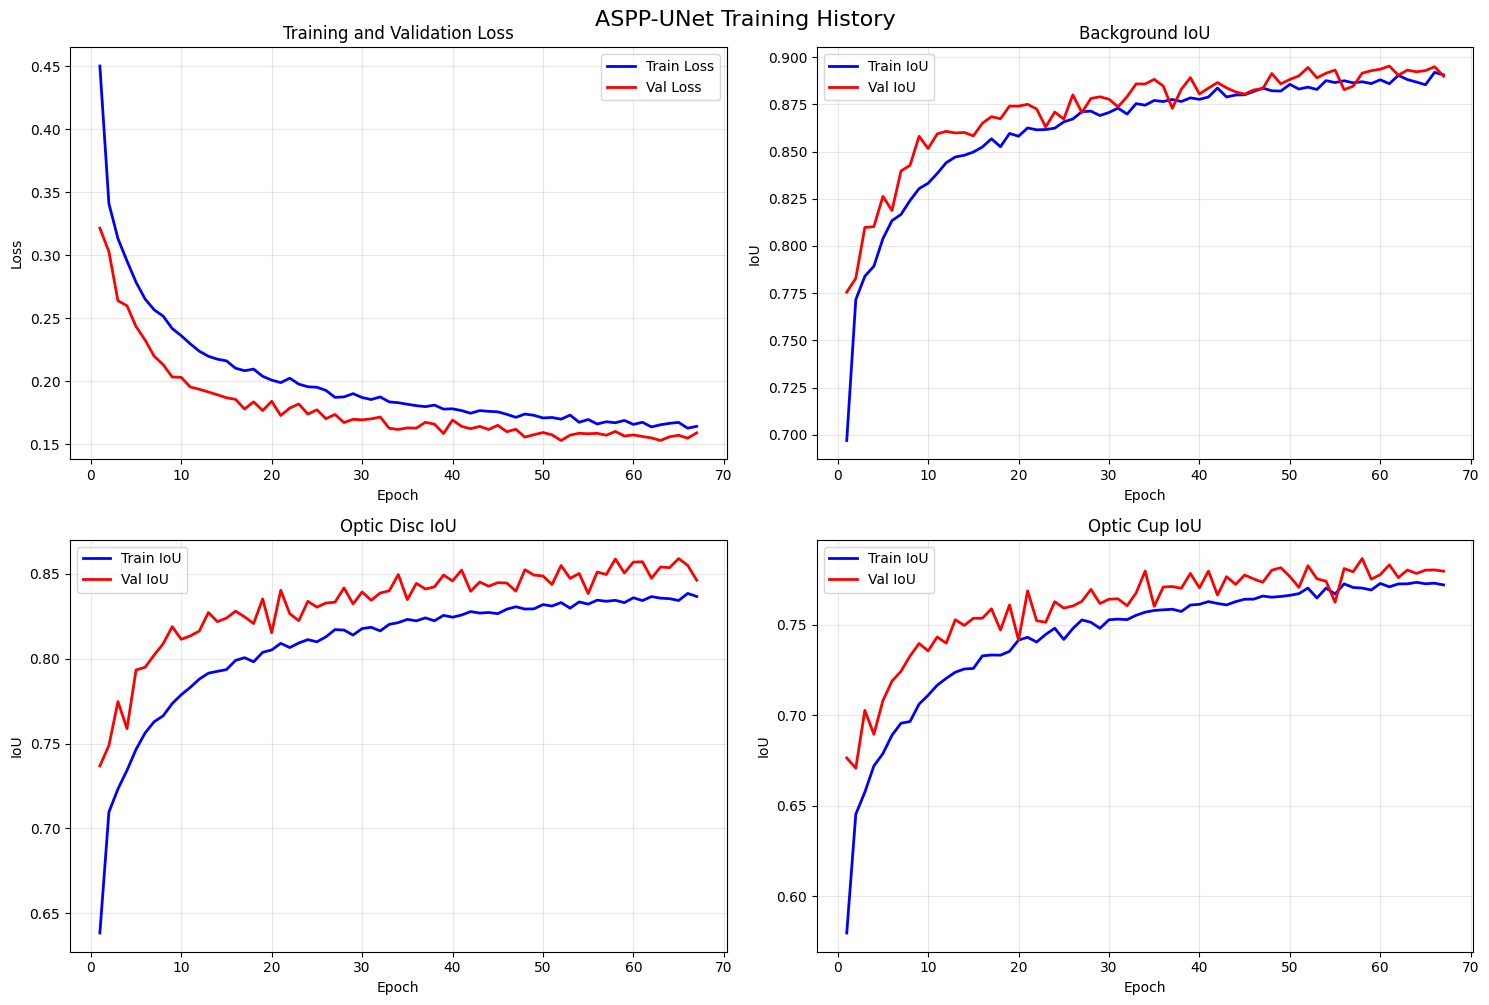

In [4]:
# Plot training history
fig = plot_training_history(
    history,
    save_path=str(project_root / 'results' / 'aspp_unet_training_history.png')
)
plt.suptitle('ASPP-UNet Training History', fontsize=16, y=1.00)
plt.show()


## 5. Print Final Metrics


## 6. Save Training History


In [5]:
print("\n" + "=" * 80)
print("FINAL TRAINING RESULTS - ASPP-UNet")
print("=" * 80)

final_epoch = len(history['train_loss'])
print(f"\nTotal Epochs: {final_epoch}")

print("\nFinal Training Metrics:")
print(f"  Loss:        {history['train_loss'][-1]:.4f}")
print(f"  IoU (BG):    {history['train_iou_bg'][-1]:.4f}")
print(f"  IoU (Disc):  {history['train_iou_disc'][-1]:.4f}")
print(f"  IoU (Cup):   {history['train_iou_cup'][-1]:.4f}")

print("\nFinal Validation Metrics:")
print(f"  Loss:        {history['val_loss'][-1]:.4f}")
print(f"  IoU (BG):    {history['val_iou_bg'][-1]:.4f}")
print(f"  IoU (Disc):  {history['val_iou_disc'][-1]:.4f}")
print(f"  IoU (Cup):   {history['val_iou_cup'][-1]:.4f}")

print("\nBest Validation Loss:")
best_epoch = history['val_loss'].index(min(history['val_loss'])) + 1
best_val_loss = min(history['val_loss'])
print(f"  Epoch: {best_epoch}")
print(f"  Loss:  {best_val_loss:.4f}")

print("\n" + "=" * 80)



FINAL TRAINING RESULTS - ASPP-UNet

Total Epochs: 67

Final Training Metrics:
  Loss:        0.1640
  IoU (BG):    0.8906
  IoU (Disc):  0.8367
  IoU (Cup):   0.7721

Final Validation Metrics:
  Loss:        0.1589
  IoU (BG):    0.8900
  IoU (Disc):  0.8463
  IoU (Cup):   0.7797

Best Validation Loss:
  Epoch: 52
  Loss:  0.1528



In [6]:
# Save history as JSON
results_dir = project_root / 'results'
results_dir.mkdir(exist_ok=True, parents=True)

history_path = results_dir / 'aspp_unet_training_history.json'
with open(history_path, 'w') as f:
    json.dump(history, f, indent=2)

print(f"Training history saved to: {history_path}")


Training history saved to: /home/robolab/dev/CAP5410-roi-enhancer-odoc/results/aspp_unet_training_history.json
